# Jensen Alpha Momentum — 12M — Equal Weight

One signal, one formation horizon and one maintenance method. The experiment contains nine cells: rebalance every 1, 3 or 6 months × target N=12, 24 or 50.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'src'))
from momentum_india.notebook_views import ResearchNotebook

research = ResearchNotebook('jensen_alpha', '12M', 'equal_weight')

## 1. Signal and portfolio rule

Daily stock excess return = alpha + beta × daily Nifty 50 excess return + residual. Both excess returns subtract the continuous liquid-fund daily return. OLS alpha is the ranking score over the fixed formation window; this is a trailing signal, not the strategy's subsequently realized alpha.

Each selected stock targets 1/N of pre-trade equity at a scheduled rebalance. If K<N qualify, target cash is (N−K)/N before charges; eligible stocks are not enlarged to 1/K. Sales precede purchases, which are reduced proportionally if charges or unfilled sales restrict available cash. Actual weights can therefore differ slightly from targets. Membership is rebuilt from current ranks without a retention buffer.

## 2. Universe → ranking → actual portfolio

The example uses the latest monthly N=24 signal and exposes the ranking inputs and actual target weights.

Symbol,Daily alpha,MDTV (INR)
NSE:CUPID-EQ,0.0090,"2,261,224,535.95"
NSE:ATHERENERG-EQ,0.0057,"2,745,338,022.88"
NSE:KMEW-EQ,0.0054,"175,654,741.20"
NSE:THANGAMAYL-EQ,0.0048,"572,585,716.40"
NSE:RPTECH-EQ,0.0047,"78,147,051.55"
NSE:HFCL-EQ,0.0045,"3,688,024,397.99"
NSE:NGLFINE-EQ,0.0044,"21,228,409.00"
NSE:AEROFLEX-EQ,0.0043,"644,982,030.67"
NSE:SILVERTUC-EQ,0.0043,"65,229,764.81"
NSE:APOLLO-EQ,0.0042,"2,231,391,532.53"


Symbol,Leg,Actual weight,Current selection,Execution status,Daily alpha,MDTV (INR)
NSE:CUPID-EQ,long,4.2%,True,selected,0.0090,"2,261,224,535.95"
NSE:ATHERENERG-EQ,long,3.5%,True,selected,0.0057,"2,745,338,022.88"
NSE:KMEW-EQ,long,4.2%,True,selected,0.0054,"175,654,741.20"
NSE:THANGAMAYL-EQ,long,3.1%,True,selected,0.0048,"572,585,716.40"
NSE:RPTECH-EQ,long,2.8%,True,selected,0.0047,"78,147,051.55"
NSE:HFCL-EQ,long,2.6%,True,selected,0.0045,"3,688,024,397.99"
NSE:NGLFINE-EQ,long,1.5%,True,selected,0.0044,"21,228,409.00"
NSE:AEROFLEX-EQ,long,3.2%,True,selected,0.0043,"644,982,030.67"
NSE:SILVERTUC-EQ,long,2.8%,True,selected,0.0043,"65,229,764.81"
NSE:APOLLO-EQ,long,3.6%,True,selected,0.0042,"2,231,391,532.53"


Symbol,Formation start,Start adjusted close,Signal close date,End adjusted close,Formation price return
NSE:CUPID-EQ,2025-07-31,30.18,2026-07-31,230.62,664.2%


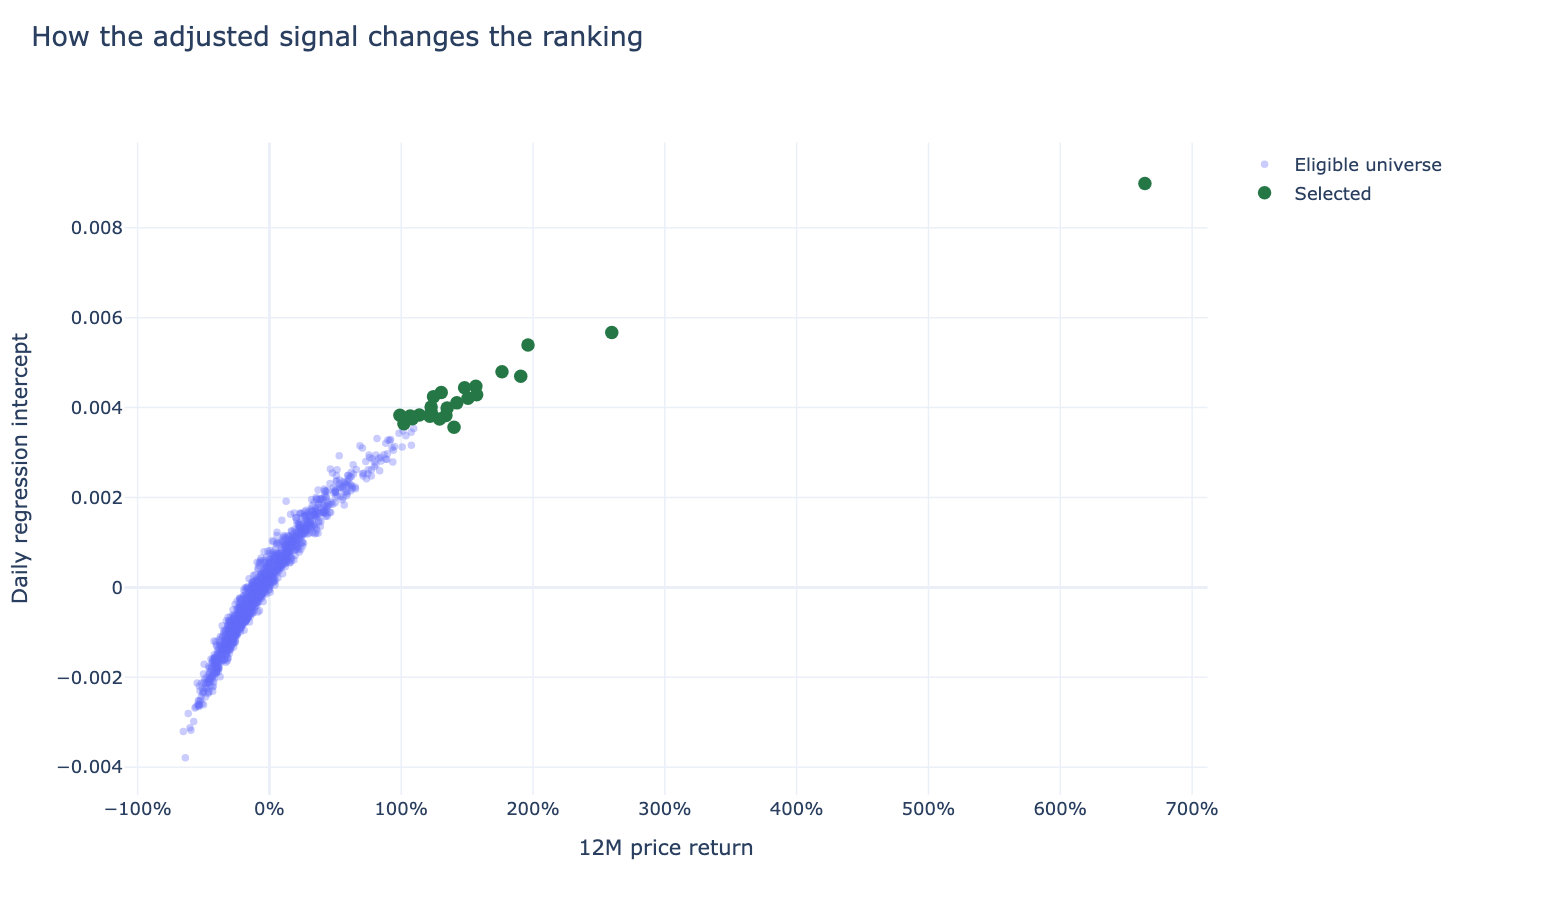

In [2]:
research.snapshot()

## 3. Return layers across all nine cells

Raw is before trading charges. After-cost gross/pre-tax deducts modeled trading charges. The long-only post-tax overlay additionally applies the annual equity-gains ledger. The academic reference instead compares raw and borrowing-adjusted layers.

In [3]:
research.layers_bridge()

Rebalance,First date,Last date,Sessions
1M,2007-05-03,2026-08-28,4771
3M,2007-07-02,2026-08-28,4729
6M,2007-07-02,2026-08-28,4729


Rebalance,N,Raw,After costs,Post-tax overlay
1M,12,12.1%,11.1%,9.7%
1M,24,14.7%,13.7%,12.2%
1M,50,16.2%,15.2%,13.6%
3M,12,12.2%,11.6%,10.1%
3M,24,13.9%,13.3%,11.8%
3M,50,13.6%,13.1%,11.8%
6M,12,10.8%,10.4%,9.2%
6M,24,10.3%,9.9%,8.7%
6M,50,10.8%,10.5%,9.6%


## 4. Risk-adjusted results

Sharpe uses daily excess returns relative to the liquid fund. VaR and expected shortfall are historical monthly 95% loss measures. Partial first/last months are included. Time below prior peak counts days awaiting a new all-time high—not losing days. The initial invested capital is included as the first peak.

In [4]:
research.risk_grid()

Rebalance,N,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,12,9.7%,0.222,-81.6%,13.3%
1M,24,12.2%,0.327,-77.1%,11.4%
1M,50,13.6%,0.396,-73.9%,10.2%
3M,12,10.1%,0.238,-79.5%,10.6%
3M,24,11.8%,0.308,-75.0%,10.9%
3M,50,11.8%,0.316,-74.3%,10.5%
6M,12,9.2%,0.199,-79.1%,11.8%
6M,24,8.7%,0.177,-73.2%,10.8%
6M,50,9.6%,0.214,-74.7%,10.4%


Rebalance,N,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,12,19.5%,96.1%,1932
1M,24,17.6%,94.4%,1720
1M,50,16.8%,92.3%,1644
3M,12,18.7%,95.3%,1653
3M,24,17.4%,94.0%,1641
3M,50,17.0%,93.4%,1599
6M,12,19.9%,95.9%,1644
6M,24,17.1%,95.1%,1599
6M,50,17.1%,94.2%,1643


### CAGR

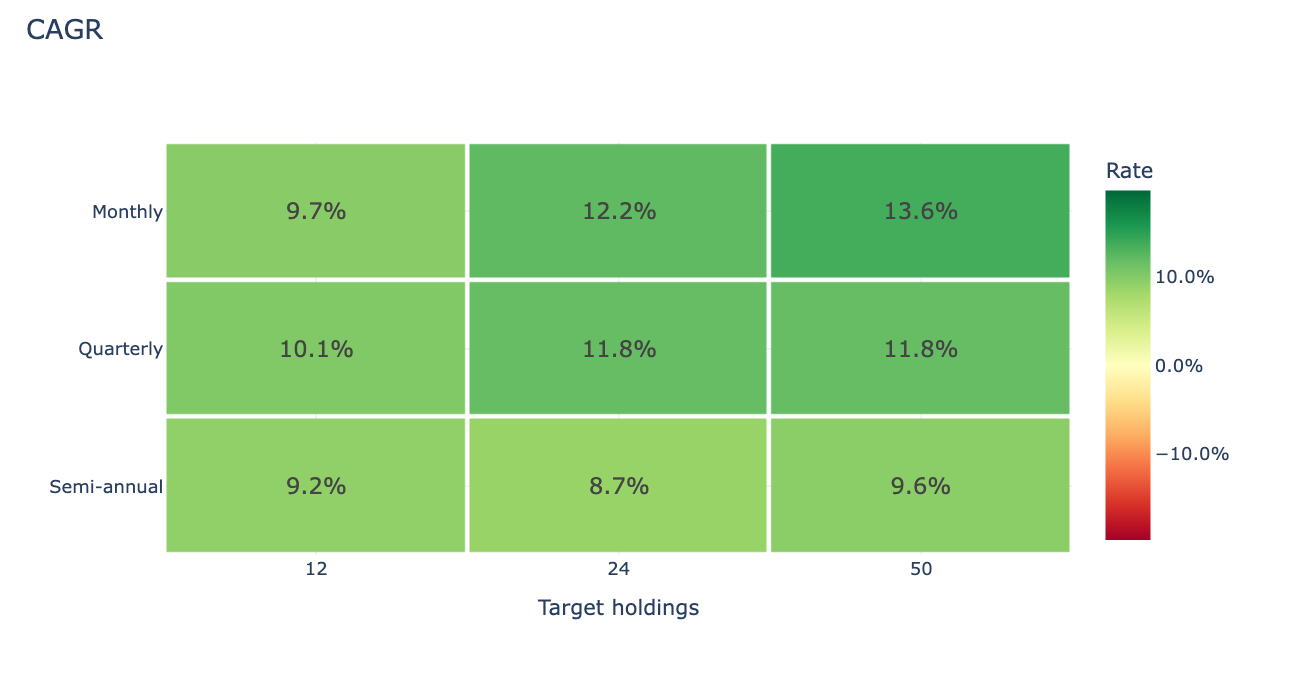

In [5]:
research.heatmap('cagr')

### Sharpe ratio

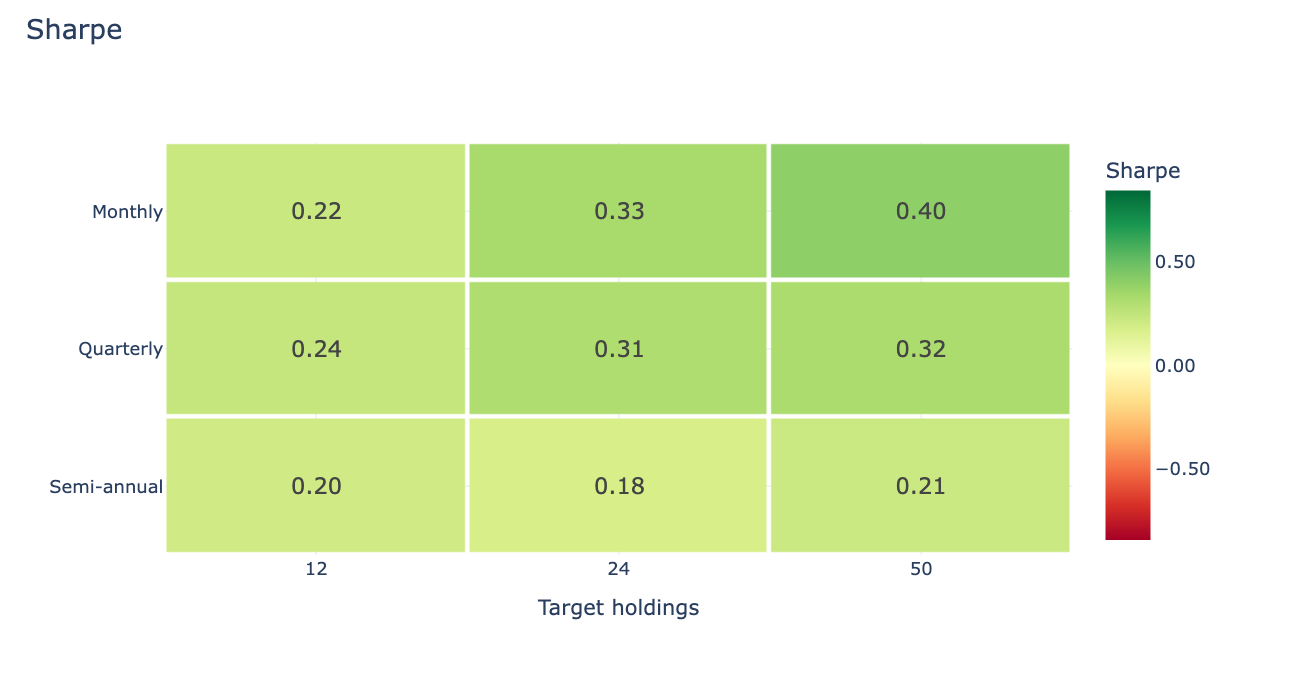

In [6]:
research.heatmap('sharpe')

### Maximum drawdown

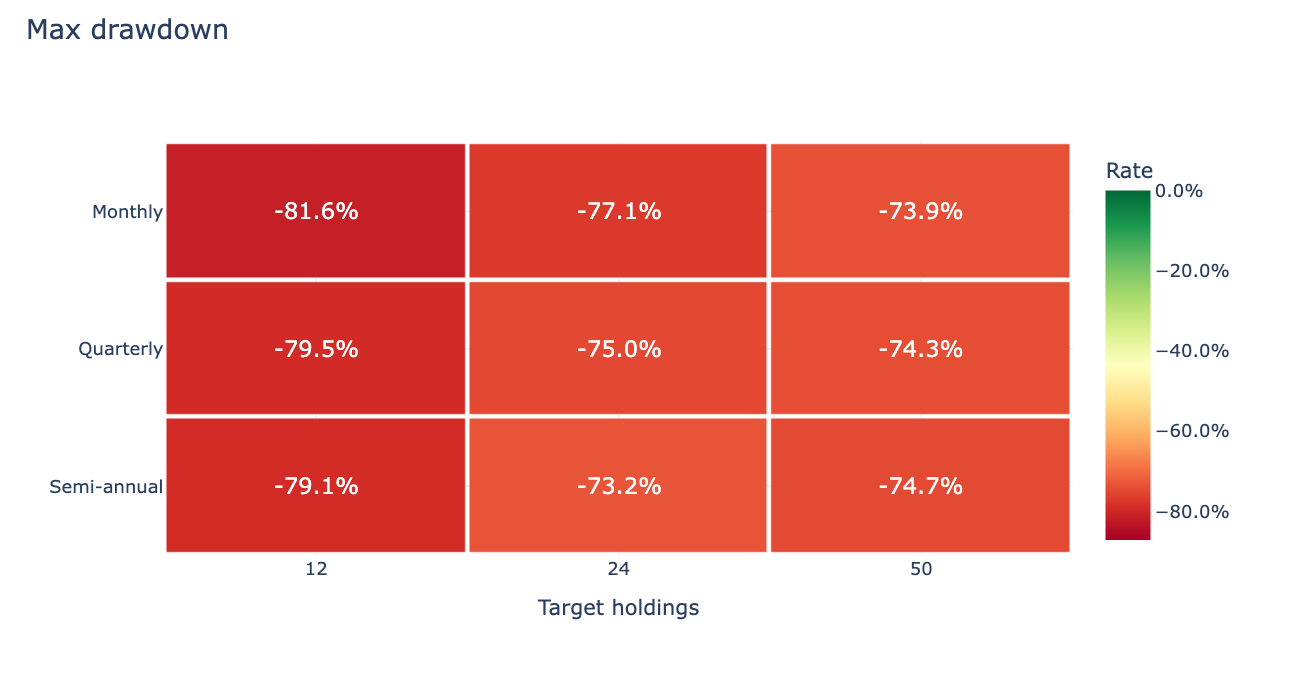

In [7]:
research.heatmap('maximum_drawdown')

### Monthly 95% VaR

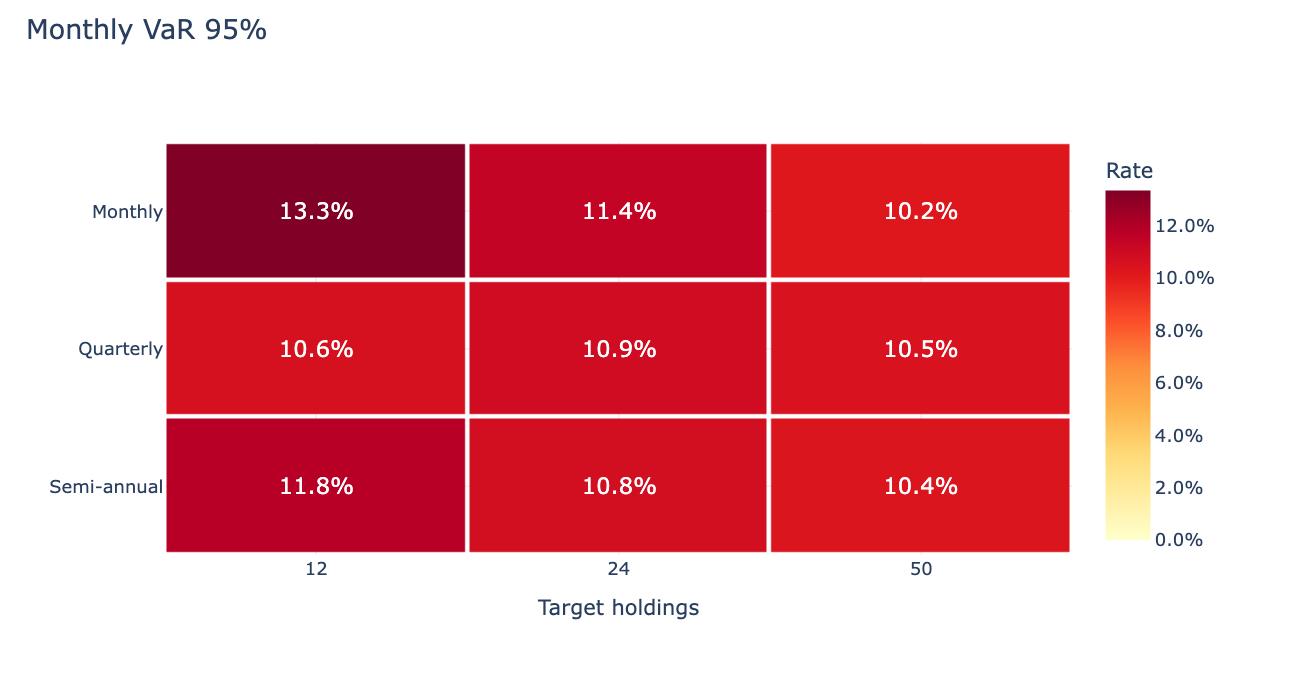

In [8]:
research.heatmap('monthly_var_95')

## 5. Equity paths and matched risks

Each chart fixes breadth and compares rebalance frequencies. Final-layer curves and the price benchmark start visible; other return layers remain in the selectable legend. Logarithmic axes make early and late periods comparable; the bottom range slider preserves the full history. Curves display weekly observations for readability, while every statistic uses the complete daily series.

### N=12

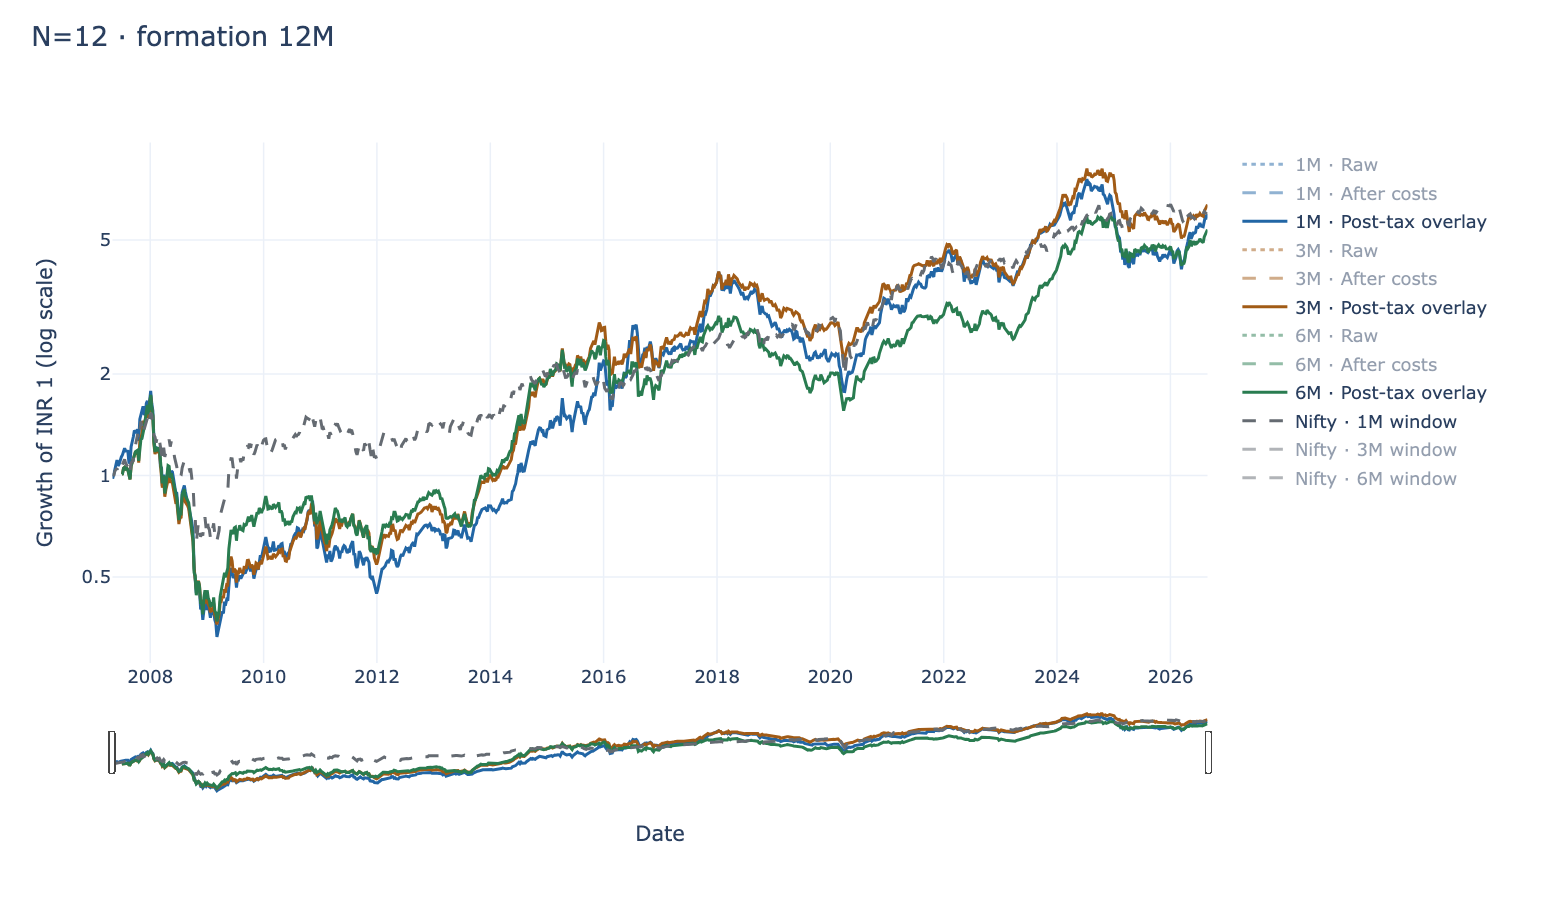

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Raw,12.1%,0.308,-80.6%,13.3%
1M,After costs,11.1%,0.271,-80.8%,13.3%
1M,Post-tax overlay,9.7%,0.222,-81.6%,13.3%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Raw,12.2%,0.320,-78.2%,10.6%
3M,After costs,11.6%,0.297,-78.3%,10.6%
3M,Post-tax overlay,10.1%,0.238,-79.5%,10.6%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%
6M,Raw,10.8%,0.262,-77.7%,11.8%
6M,After costs,10.4%,0.247,-77.7%,11.8%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Raw,19.2%,95.3%,1783
1M,After costs,19.2%,95.6%,1918
3M,Raw,18.3%,94.7%,1643
3M,After costs,18.3%,94.8%,1644
6M,Raw,19.4%,95.5%,1637
6M,After costs,19.4%,95.7%,1642
1M,Post-tax overlay,19.5%,96.1%,1932
3M,Post-tax overlay,18.7%,95.3%,1653
6M,Post-tax overlay,19.9%,95.9%,1644
1M,Nifty 50 price,13.1%,92.4%,1520


In [9]:
research.equity(12)

### N=24

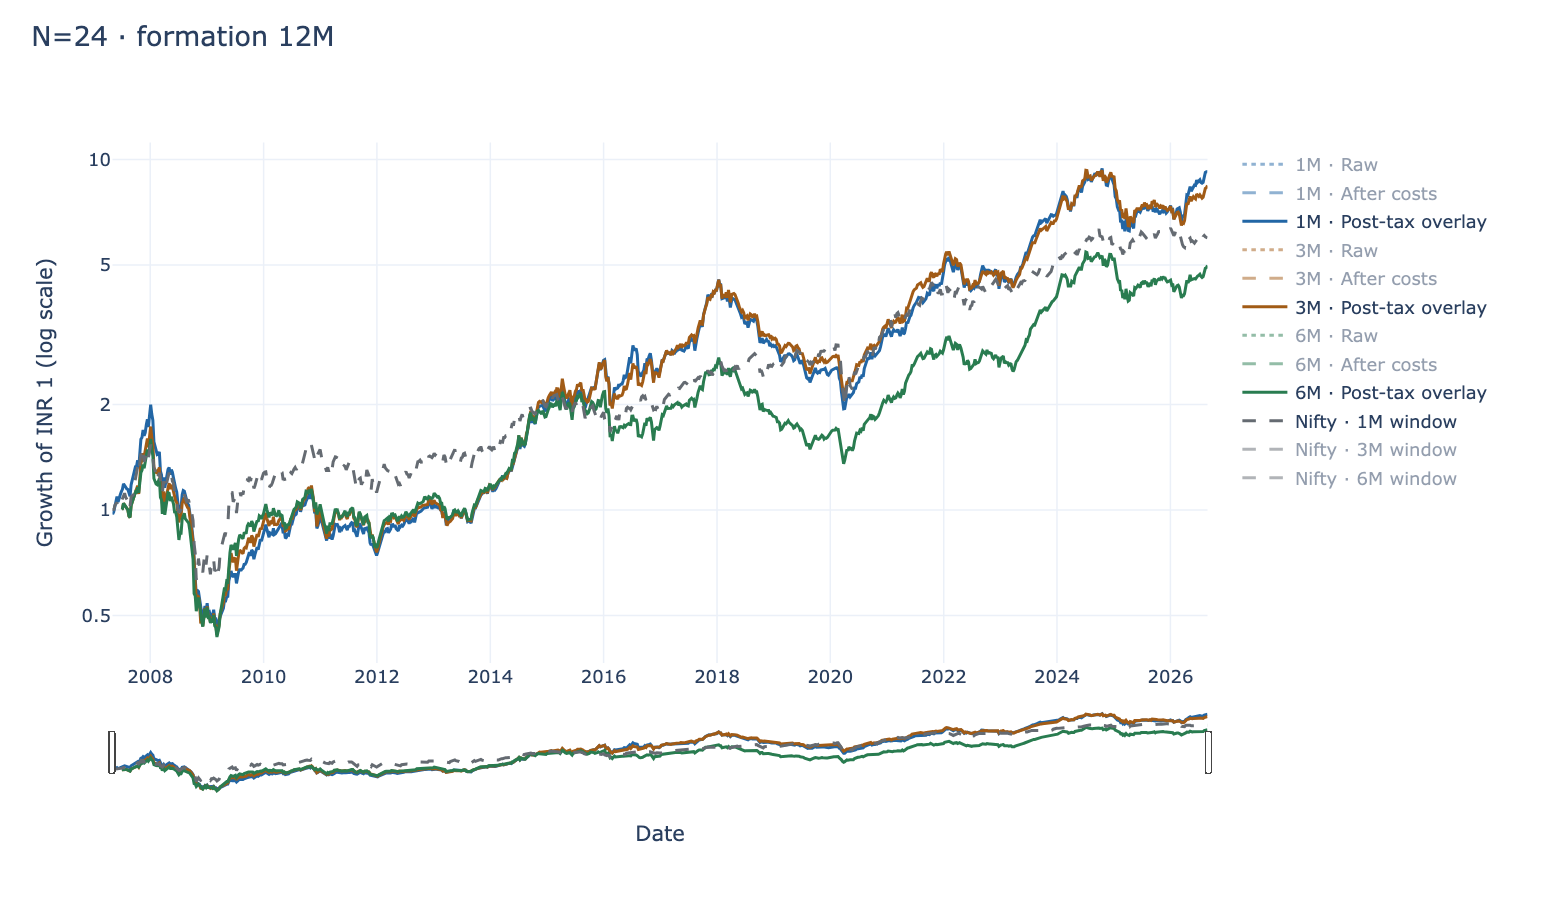

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Raw,14.7%,0.433,-76.4%,11.4%
1M,After costs,13.7%,0.392,-76.6%,11.4%
1M,Post-tax overlay,12.2%,0.327,-77.1%,11.4%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Raw,13.9%,0.396,-74.2%,10.9%
3M,After costs,13.3%,0.372,-74.3%,10.9%
3M,Post-tax overlay,11.8%,0.308,-75.0%,10.9%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%
6M,Raw,10.3%,0.245,-72.2%,10.8%
6M,After costs,9.9%,0.229,-72.3%,10.8%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Raw,17.4%,93.2%,1654
1M,After costs,17.4%,93.8%,1681
3M,Raw,17.2%,93.3%,1601
3M,After costs,17.2%,93.5%,1639
6M,Raw,16.8%,94.5%,1592
6M,After costs,16.8%,94.8%,1596
1M,Post-tax overlay,17.6%,94.4%,1720
3M,Post-tax overlay,17.4%,94.0%,1641
6M,Post-tax overlay,17.1%,95.1%,1599
1M,Nifty 50 price,13.1%,92.4%,1520


In [10]:
research.equity(24)

### N=50

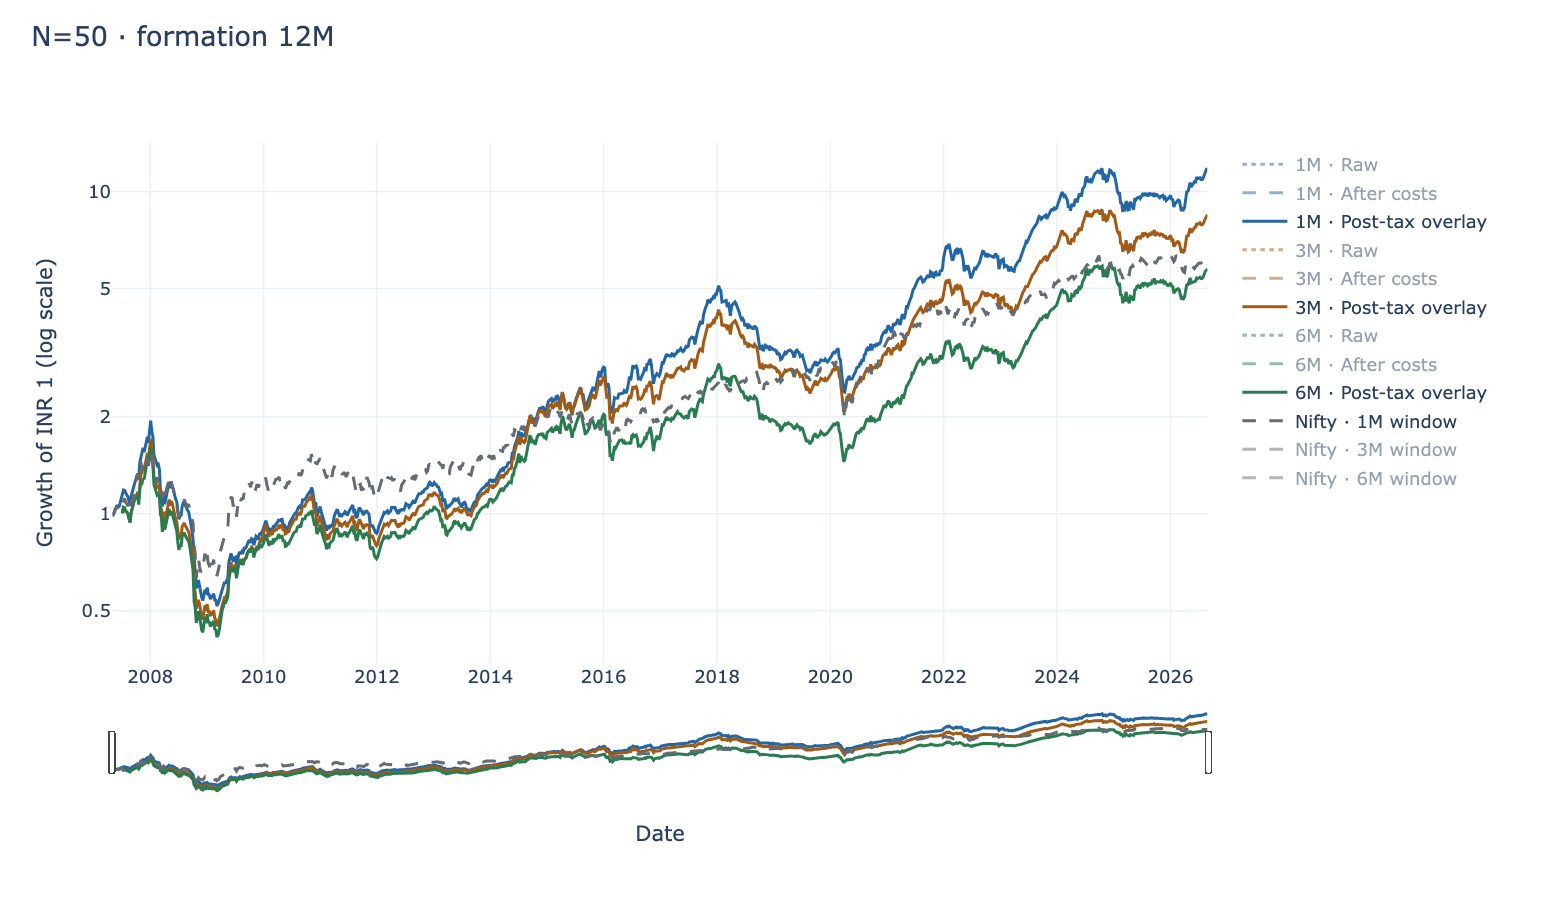

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Raw,16.2%,0.510,-72.9%,9.9%
1M,After costs,15.2%,0.468,-73.2%,9.9%
1M,Post-tax overlay,13.6%,0.396,-73.9%,10.2%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Raw,13.6%,0.398,-73.1%,10.5%
3M,After costs,13.1%,0.373,-73.3%,10.5%
3M,Post-tax overlay,11.8%,0.316,-74.3%,10.5%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%
6M,Raw,10.8%,0.274,-73.5%,10.4%
6M,After costs,10.5%,0.257,-73.6%,10.4%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Raw,16.6%,91.3%,1599
1M,After costs,16.6%,91.7%,1643
3M,Raw,16.7%,92.6%,1587
3M,After costs,16.7%,93.0%,1596
6M,Raw,16.8%,93.4%,1599
6M,After costs,16.8%,93.7%,1634
1M,Post-tax overlay,16.8%,92.3%,1644
3M,Post-tax overlay,17.0%,93.4%,1599
6M,Post-tax overlay,17.1%,94.2%,1643
1M,Nifty 50 price,13.1%,92.4%,1520


In [11]:
research.equity(50)

## 6. Recovery burden

The longest underwater episode is shown by its peak, trough and recovery dates. Unrecovered episodes remain explicitly open.

In [12]:
research.recovery()

Series,Peak,Trough,Recovery,Sessions,Calendar days,Episode loss
1M,2008-01-07,2009-03-09,2015-01-02,1720,2551,-77.1%
3M,2008-01-07,2009-03-09,2014-09-03,1641,2430,-75.0%
6M,2008-01-07,2009-03-09,2014-07-02,1599,2367,-73.2%
Nifty · 1M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%
Nifty · 3M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%
Nifty · 6M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%


## 7. Portfolio behavior

Scheduled turnover is (buy value + sell value)/(2 × pre-trade equity). Retention compares successive scheduled target name sets. Cash and total charges include the intervening daily path.

In [13]:
research.behavior()

Rebalance,N,Mean names at rebalance,Mean cash weight,Scheduled name retention
1M,12,17.09,1.1%,73.1%
1M,24,35.37,0.8%,76.5%
1M,50,72.17,0.6%,78.5%
3M,12,17.23,1.4%,54.2%
3M,24,33.88,1.3%,57.5%
3M,50,69.75,1.2%,61.6%
6M,12,16.00,1.7%,36.5%
6M,24,33.31,1.1%,42.6%
6M,50,68.51,1.3%,46.2%


Rebalance,N,Mean scheduled turnover,All trading charges (INR),Days with stop sales
1M,12,27.8%,"4,187,118.68",0
1M,24,22.6%,"4,578,326.78",0
1M,50,21.1%,"5,409,305.53",0
3M,12,43.0%,"2,421,271.98",0
3M,24,41.8%,"2,752,619.25",0
3M,50,38.9%,"2,584,047.15",0
6M,12,60.1%,"1,330,977.96",0
6M,24,56.9%,"1,270,330.97",0
6M,50,53.7%,"1,280,624.72",0


## 8. Market-state attribution

This is an observation, not an extra strategy filter. Prior-close Nifty 50 versus SMA(200) defines up/down; 63-session volatility versus its expanding historical median defines high/low volatility. The representative monthly N=24 path is shown with shaded states.

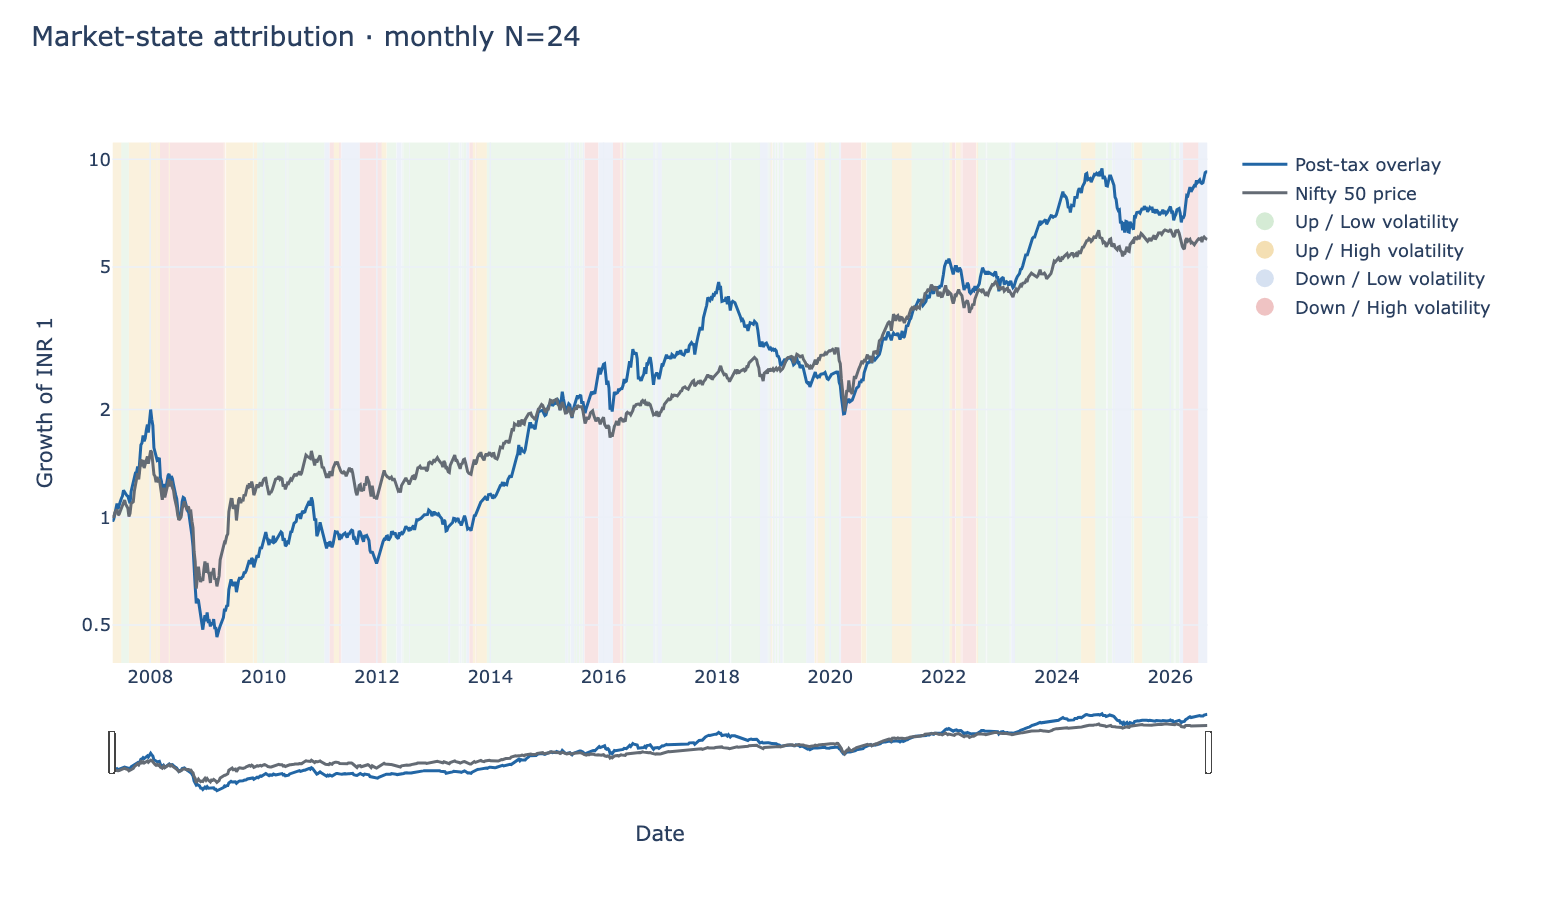

Market state,Sessions,Mean daily return,Daily volatility,Positive days
Down / High volatility,748,-0.03%,1.59%,54.01%
Down / Low volatility,609,0.00%,1.56%,51.89%
Up / High volatility,720,0.21%,1.42%,62.08%
Up / Low volatility,2694,0.05%,1.16%,56.94%


In [14]:
research.regimes()

## 9. Complete portfolio and trade evidence

Risk metrics are included in the repository. Complete portfolio and trade CSVs belong to the local full-data research run.

In [15]:
research.portfolio_exports()

Rebalance,N,First rebalance,Last rebalance,Rebalance dates,Holding rows
1M,12,2007-05-03,2026-08-03,232,3964
1M,24,2007-05-03,2026-08-03,232,8206
1M,50,2007-05-03,2026-08-03,232,16743
3M,12,2007-07-02,2026-07-01,77,1327
3M,24,2007-07-02,2026-07-01,77,2609
3M,50,2007-07-02,2026-07-01,77,5371
6M,12,2007-07-02,2026-07-01,39,624
6M,24,2007-07-02,2026-07-01,39,1299
6M,50,2007-07-02,2026-07-01,39,2672


## Findings

In [16]:
research.conclusion()

Matched reference: [Raw Momentum — 12M — Equal Weight](04_raw_momentum_12m_equal_weight.ipynb). The comparison holds formation, maintenance, frequency and N fixed.